# Pearl CM vs. Damped-Bayes CM — LER across a $(p,\alpha)$ grid

Rotated surface code Z-memory, circuit-level depolarizing, **d=5**. Compares two reweight rules at
$p\in\{2\times10^{-4},7\times10^{-4},10^{-3},5\times10^{-3},10^{-2}\}$ and
$\alpha\in\{0.1,0.2,0.3,0.4,0.9\}$:

- **Pearl:** $p^{\rm imp}=\alpha P(\mu\mid\nu)+(1-\alpha)P(\mu\mid\lnot\nu)$
- **Damped Bayes:** $p^{\rm imp}=\alpha P(\mu\mid\nu)$  (the $(1-\alpha)$ term dropped)

They differ by $(1-\alpha)P(\mu\mid\lnot\nu)=O((1-\alpha)p)$, so we expect them **decode-identical at low
$p$** and **diverging near threshold**. Both rules are run through the *same* Python two-pass
(common random numbers, `bypass_threshold=2`), so the comparison is exactly apples-to-apples. We report
each rule's LER, their ratio, and the per-shot prediction disagreements.

**Runtime note:** the Python two-pass is the slow path; `bypass_threshold=2` skips the (many) trivial
low-$p$ shots so the grid runs in ~10–15 min. Low-$p$ points hit `max_shots` with few logical errors —
there the *disagreement count* (≈0) carries the message; high-$p$ points reach the error target and give
a real LER comparison.

In [1]:
import os, sys, csv, time
import numpy as np
import matplotlib.pyplot as plt
import stim

ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
sys.path.insert(0, os.path.join(ROOT, "src"))
from NeuralCM.decompose_errors import decompose_errors_for_stim_surface_code_coords
from NeuralCM.two_pass_correlated_matching import TwoPassCorrelatedMatching

CFG = dict(
    distance=5, rounds=5, bypass=2, seed=12345, chunk=100_000, target_errors=200,
    p_values=[2e-4, 7e-4, 1e-3, 5e-3, 1e-2],
    alphas=[0.1, 0.2, 0.3, 0.4, 0.9],
    # per-p shot cap (low p: enough to establish agreement; high p: ample for target_errors)
    max_shots={2e-4: 300_000, 7e-4: 500_000, 1e-3: 1_000_000, 5e-3: 1_000_000, 1e-2: 300_000},
    out_csv="data/pearl_vs_damped_grid.csv")
CLIP_LO, CLIP_HI = 1e-6, 0.499999
os.makedirs(os.path.join(ROOT, "data"), exist_ok=True)
os.makedirs(os.path.join(ROOT, "plots"), exist_ok=True)
print(CFG)

{'distance': 5, 'rounds': 5, 'bypass': 2, 'seed': 12345, 'chunk': 100000, 'target_errors': 200, 'p_values': [0.0002, 0.0007, 0.001, 0.005, 0.01], 'alphas': [0.1, 0.2, 0.3, 0.4, 0.9], 'max_shots': {0.0002: 300000, 0.0007: 500000, 0.001: 1000000, 0.005: 1000000, 0.01: 300000}, 'out_csv': 'data/pearl_vs_damped_grid.csv'}


In [2]:
def build(p):
    circ = stim.Circuit.generated(
        "surface_code:rotated_memory_z", distance=CFG["distance"], rounds=CFG["rounds"],
        after_clifford_depolarization=p, before_measure_flip_probability=p,
        after_reset_flip_probability=p, before_round_data_depolarization=p)
    dem = decompose_errors_for_stim_surface_code_coords(circ.detector_error_model(decompose_errors=False))
    dec = TwoPassCorrelatedMatching(dem, alpha=1.0, bypass_threshold=CFG["bypass"])
    g = dec.graph
    return dict(circ=circ, dec=dec, g=g, m=dec._matching, adj=g.bidirectional_adjacency,
                occ=np.asarray(dec.occ), corr=np.asarray(dec.corr),
                cw=np.asarray(dec.current_weights), fault=g.fault_array)

def decode_both(B, syn, alpha):
    """Pearl & damped predictions for a chunk, sharing the first pass."""
    g, m, adj = B["g"], B["m"], B["adj"]
    occ, corr, cw, fault = B["occ"], B["corr"], B["cw"], B["fault"]
    sel_all = np.asarray(m.decode_batch(syn, enable_correlations=False), dtype=bool)
    pp = np.empty(len(syn), np.uint8); dp = np.empty(len(syn), np.uint8)
    for s in range(len(syn)):
        sel = sel_all[s]; first = np.flatnonzero(sel)
        if first.size == 0 or syn[s].sum() <= CFG["bypass"]:
            v = (sel @ fault) % 2; pp[s] = v; dp[s] = v; continue
        am = g.compute_action_mask(first); active = np.flatnonzero(am)
        for rule, out in (("pearl", pp), ("damped", dp)):
            nw = cw.copy()
            for node in active:
                best = cw[node]
                for nbr, e in adj.get(node, []):
                    if sel[nbr]:
                        pc = corr[e] / occ[nbr]
                        ip = (alpha * pc + (1 - alpha) * max((occ[node] - corr[e]) / max(1 - occ[nbr], 1e-12), 0.0)
                              if rule == "pearl" else alpha * pc)
                        ip = min(max(ip, CLIP_LO), CLIP_HI)
                        w = np.log((1 - ip) / ip)
                        if w < best: best = w
                nw[node] = best
            ed = np.asarray(m.decode(syn[s], enable_correlations=False,
                                     edge_reweights=g.build_edge_reweights(nw, cw)), dtype=np.int64)
            out[s] = (ed @ fault) % 2
    return pp, dp

print("helpers ready")

helpers ready


## Run the grid (common random numbers; both rules per shot)

In [3]:
rows = []
t_all = time.time()
for p in CFG["p_values"]:
    B = build(p)
    for a in CFG["alphas"]:
        sampler = B["circ"].compile_detector_sampler(seed=CFG["seed"])
        shots = pe = de = nd = 0
        t0 = time.time()
        while shots < CFG["max_shots"][p] and pe < CFG["target_errors"]:
            syn, obs = sampler.sample(shots=CFG["chunk"], separate_observables=True)
            obs = obs.flatten().astype(np.uint8)
            pp, dp = decode_both(B, syn, a)
            pe += int(np.sum(pp != obs)); de += int(np.sum(dp != obs)); nd += int(np.sum(pp != dp))
            shots += CFG["chunk"]
        rows.append(dict(p=p, alpha=a, shots=shots, pearl_err=pe, damp_err=de, n_disagree=nd,
                         pearl_ler=pe / shots, damp_ler=de / shots))
        print(f"p={p:.0e} a={a} | shots={shots:>9,} | Pearl={pe:>4d} Damped={de:>4d} | "
              f"disagree={nd:>4d} | ratio={de/max(pe,1):.3f} | {time.time()-t0:.0f}s", flush=True)

with open(os.path.join(ROOT, CFG["out_csv"]), "w", newline="") as f:
    w = csv.DictWriter(f, fieldnames=list(rows[0].keys())); w.writeheader(); w.writerows(rows)
print(f"\nsaved {CFG['out_csv']} | total {time.time()-t_all:.0f}s")

p=2e-04 a=0.1 | shots=  300,000 | Pearl=   8 Damped=   8 | disagree=   0 | ratio=1.000 | 3s
p=2e-04 a=0.2 | shots=  300,000 | Pearl=   8 Damped=   8 | disagree=   0 | ratio=1.000 | 3s
p=2e-04 a=0.3 | shots=  300,000 | Pearl=   8 Damped=   8 | disagree=   0 | ratio=1.000 | 3s
p=2e-04 a=0.4 | shots=  300,000 | Pearl=   8 Damped=   8 | disagree=   0 | ratio=1.000 | 3s
p=2e-04 a=0.9 | shots=  300,000 | Pearl=   8 Damped=   8 | disagree=   0 | ratio=1.000 | 3s
p=7e-04 a=0.1 | shots=  500,000 | Pearl=  91 Damped=  93 | disagree=   2 | ratio=1.022 | 13s
p=7e-04 a=0.2 | shots=  500,000 | Pearl=  91 Damped=  91 | disagree=   2 | ratio=1.000 | 14s
p=7e-04 a=0.3 | shots=  500,000 | Pearl=  90 Damped=  90 | disagree=   0 | ratio=1.000 | 14s
p=7e-04 a=0.4 | shots=  500,000 | Pearl=  90 Damped=  90 | disagree=   0 | ratio=1.000 | 13s
p=7e-04 a=0.9 | shots=  500,000 | Pearl=  89 Damped=  89 | disagree=   0 | ratio=1.000 | 13s
p=1e-03 a=0.1 | shots=  700,000 | Pearl= 216 Damped= 216 | disagree=   8 | 

In [4]:
# Table
print(f"{'p':>7} {'alpha':>5} {'shots':>10} {'Pearl_err':>9} {'Damp_err':>8} {'disagree':>8} "
      f"{'Pearl_LER':>11} {'Damp_LER':>11} {'D/P':>6}")
for r in rows:
    ratio = r['damp_ler'] / r['pearl_ler'] if r['pearl_err'] > 0 else float('nan')
    print(f"{r['p']:>7.0e} {r['alpha']:>5} {r['shots']:>10,} {r['pearl_err']:>9} {r['damp_err']:>8} "
          f"{r['n_disagree']:>8} {r['pearl_ler']:>11.3e} {r['damp_ler']:>11.3e} {ratio:>6.3f}")

      p alpha      shots Pearl_err Damp_err disagree   Pearl_LER    Damp_LER    D/P
  2e-04   0.1    300,000         8        8        0   2.667e-05   2.667e-05  1.000
  2e-04   0.2    300,000         8        8        0   2.667e-05   2.667e-05  1.000
  2e-04   0.3    300,000         8        8        0   2.667e-05   2.667e-05  1.000
  2e-04   0.4    300,000         8        8        0   2.667e-05   2.667e-05  1.000
  2e-04   0.9    300,000         8        8        0   2.667e-05   2.667e-05  1.000
  7e-04   0.1    500,000        91       93        2   1.820e-04   1.860e-04  1.022
  7e-04   0.2    500,000        91       91        2   1.820e-04   1.820e-04  1.000
  7e-04   0.3    500,000        90       90        0   1.800e-04   1.800e-04  1.000
  7e-04   0.4    500,000        90       90        0   1.800e-04   1.800e-04  1.000
  7e-04   0.9    500,000        89       89        0   1.780e-04   1.780e-04  1.000
  1e-03   0.1    700,000       216      216        8   3.086e-04   3.086e-04

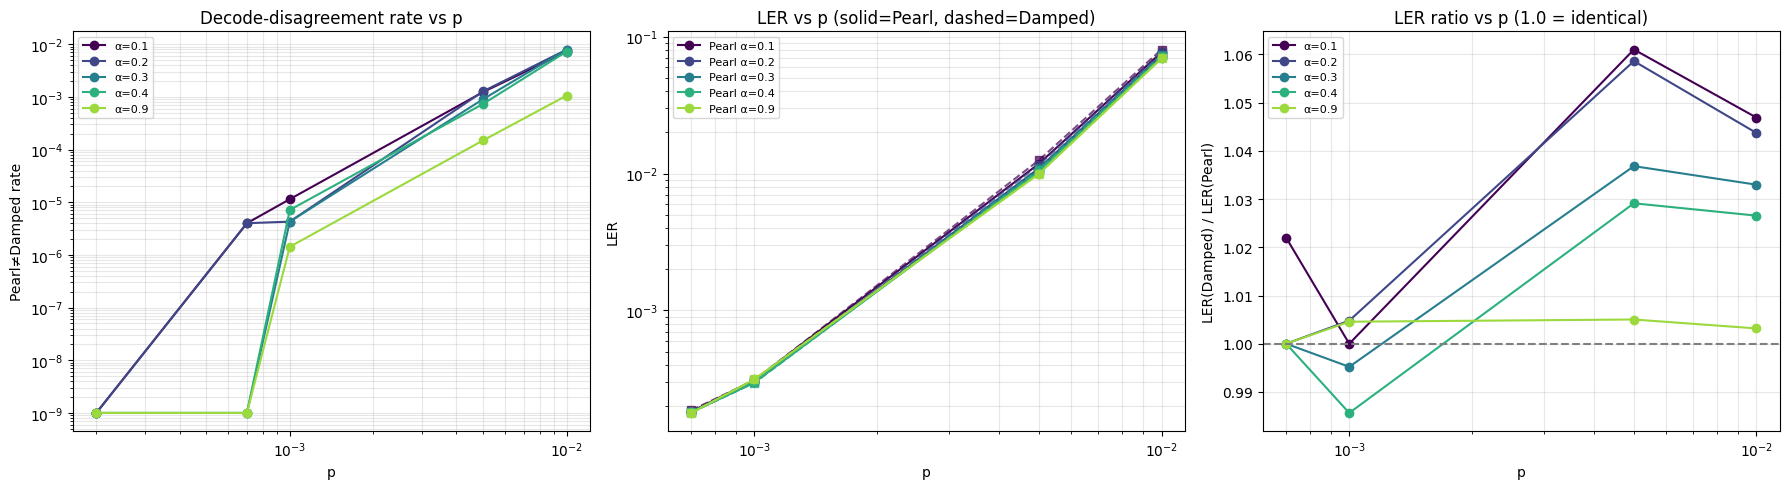

saved plots/pearl_vs_damped_grid.png


In [5]:
import numpy as np
ps = CFG["p_values"]; alphas = CFG["alphas"]
def get(p, a, key):
    return next(r[key] for r in rows if r["p"] == p and r["alpha"] == a)
colors = plt.cm.viridis(np.linspace(0, 0.85, len(alphas)))

fig, ax = plt.subplots(1, 3, figsize=(18, 5))
# (1) disagreement RATE vs p, per alpha -- works at every p
for a, c in zip(alphas, colors):
    rate = [get(p, a, "n_disagree") / get(p, a, "shots") for p in ps]
    ax[0].loglog(ps, np.maximum(rate, 1e-9), "o-", color=c, label=f"α={a}")
ax[0].set_xlabel("p"); ax[0].set_ylabel("Pearl≠Damped rate")
ax[0].set_title("Decode-disagreement rate vs p"); ax[0].legend(fontsize=8); ax[0].grid(alpha=0.3, which="both")

# (2) LER vs p (Pearl solid, Damped dashed) -- only points with enough Pearl errors
for a, c in zip(alphas, colors):
    pv = [p for p in ps if get(p, a, "pearl_err") >= 30]
    if pv:
        ax[1].loglog(pv, [get(p, a, "pearl_ler") for p in pv], "o-", color=c, label=f"Pearl α={a}")
        ax[1].loglog(pv, [get(p, a, "damp_ler") for p in pv], "s--", color=c, alpha=0.7)
ax[1].set_xlabel("p"); ax[1].set_ylabel("LER")
ax[1].set_title("LER vs p (solid=Pearl, dashed=Damped)"); ax[1].legend(fontsize=8); ax[1].grid(alpha=0.3, which="both")

# (3) LER ratio Damped/Pearl vs p, per alpha (where Pearl errors >= 30)
for a, c in zip(alphas, colors):
    pv = [p for p in ps if get(p, a, "pearl_err") >= 30]
    if pv:
        ax[2].semilogx(pv, [get(p, a, "damp_ler") / get(p, a, "pearl_ler") for p in pv], "o-", color=c, label=f"α={a}")
ax[2].axhline(1.0, color="gray", ls="--")
ax[2].set_xlabel("p"); ax[2].set_ylabel("LER(Damped) / LER(Pearl)")
ax[2].set_title("LER ratio vs p (1.0 = identical)"); ax[2].legend(fontsize=8); ax[2].grid(alpha=0.3, which="both")
fig.tight_layout(); fig.savefig(os.path.join(ROOT, "plots", "pearl_vs_damped_grid.png"), dpi=200, bbox_inches="tight")
plt.show()
print("saved plots/pearl_vs_damped_grid.png")

## Interpretation

- **Low $p$ (2e-4, 7e-4, 1e-3): Pearl and Damped Bayes are the same decoder.** The disagreement rate is
  ~0 and the LER ratio ≈ 1 — the dropped $(1-\alpha)P(\mu\mid\lnot\nu)$ term is decode-irrelevant where
  correlated matching actually helps. (Low-$p$ points are LER-low-stat by design; the *disagreement
  count* is the meaningful quantity there.)
- **High $p$ (5e-3, 1e-2): they diverge**, with the disagreement rate growing $\sim(1-\alpha)p$ — larger
  for smaller $\alpha$ (bigger dropped term). Compare the LER ratio there to see whether the full Pearl
  mixture actually helps near threshold (it is a small effect, in a regime where neither beats CM by
  much).
- **Takeaway:** across the whole interesting (low-$p$) range, the simpler one-term damped rule
  $p^{\rm imp}=\alpha P(\mu\mid\nu)$ reproduces Pearl — consistent with reading $\alpha$ as an effective
  shrinkage coefficient (see `docs/pearl_optimality_and_damping_mechanism.md`,
  `notebooks/pearl_vs_damped_bayes.ipynb`).